In [1]:
# ============================================
# IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from plotly.subplots import make_subplots

In [2]:
# ============================================
# LOAD DATASET
# ============================================

df = pd.read_csv("sales_data.csv")

print("Dataset Loaded Successfully!")

df.head()

Dataset Loaded Successfully!


,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


In [3]:
# ============================================
# DATASET INFORMATION
# ============================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         100 non-null    object
 1   Product      100 non-null    object
 2   Quantity     100 non-null    int64 
 3   Price        100 non-null    int64 
 4   Customer_ID  100 non-null    object
 5   Region       100 non-null    object
 6   Total_Sales  100 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 5.6+ KB


In [4]:
# ============================================
# STATISTICAL SUMMARY
# ============================================

df.describe()

,Quantity,Price,Total_Sales
count,100.000000,100.000000,100.000000
mean,4.780000,25808.510000,123650.480000
std,2.588163,13917.630242,100161.085275
min,1.000000,1308.000000,6540.000000
25%,2.750000,14965.250000,39517.500000
50%,5.000000,24192.000000,97955.500000
75%,7.000000,38682.250000,175792.500000
max,9.000000,49930.000000,373932.000000


In [5]:
# ============================================
# CHECK MISSING VALUES
# ============================================

df.isnull().sum()

Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64

In [6]:
# ============================================
# DATA CLEANING
# ============================================

# Remove duplicates
df.drop_duplicates(inplace=True)

# Fill numeric missing values
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical missing values
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Data Cleaning Completed!")

Data Cleaning Completed!


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10964\4135544301.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10964\4135544301.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

In [7]:
# ============================================
# DATE CONVERSION
# ============================================

df['Date'] = pd.to_datetime(df['Date'])

df['Month'] = df['Date'].dt.month_name()

df.head()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales,Month
0,2024-01-01,Phone,7,37300,CUST001,East,261100,January
1,2024-01-02,Headphones,4,15406,CUST002,North,61624,January
2,2024-01-03,Phone,2,21746,CUST003,West,43492,January
3,2024-01-04,Headphones,1,30895,CUST004,East,30895,January
4,2024-01-05,Laptop,8,39835,CUST005,North,318680,January


In [8]:
# ============================================
# DASHBOARD STYLE
# ============================================

sns.set_style("whitegrid")

plt.style.use("ggplot")

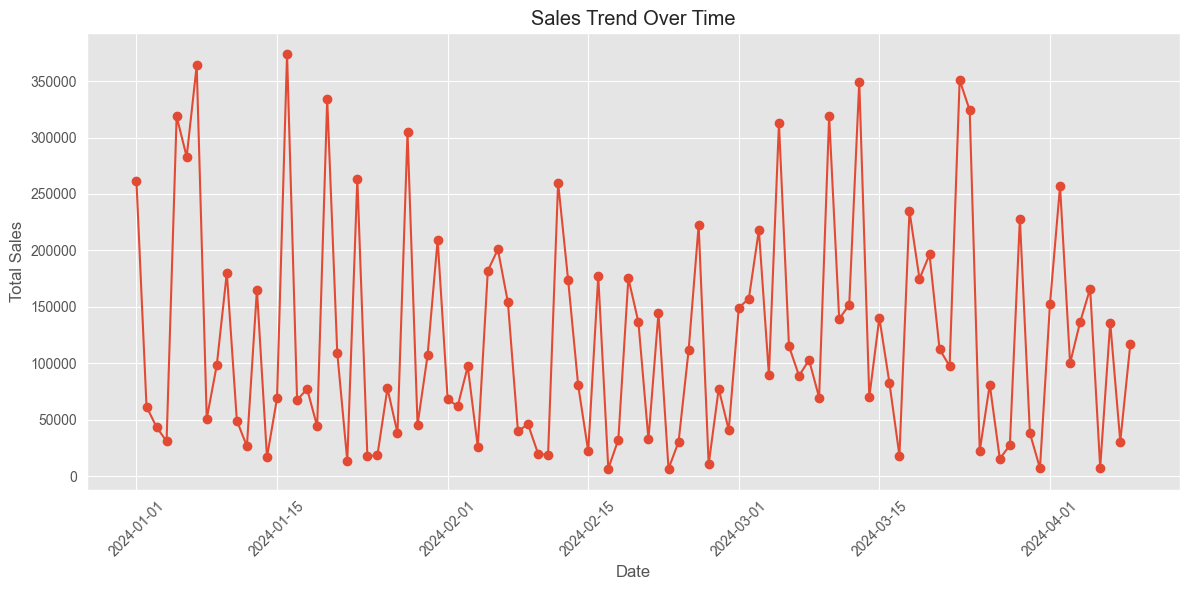

In [9]:
# ============================================
# SALES TREND LINE CHART
# ============================================

sales_trend = df.groupby('Date')['Total_Sales'].sum()

plt.figure(figsize=(12,6))

plt.plot(
    sales_trend.index,
    sales_trend.values,
    marker='o'
)

plt.title("Sales Trend Over Time")

plt.xlabel("Date")

plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

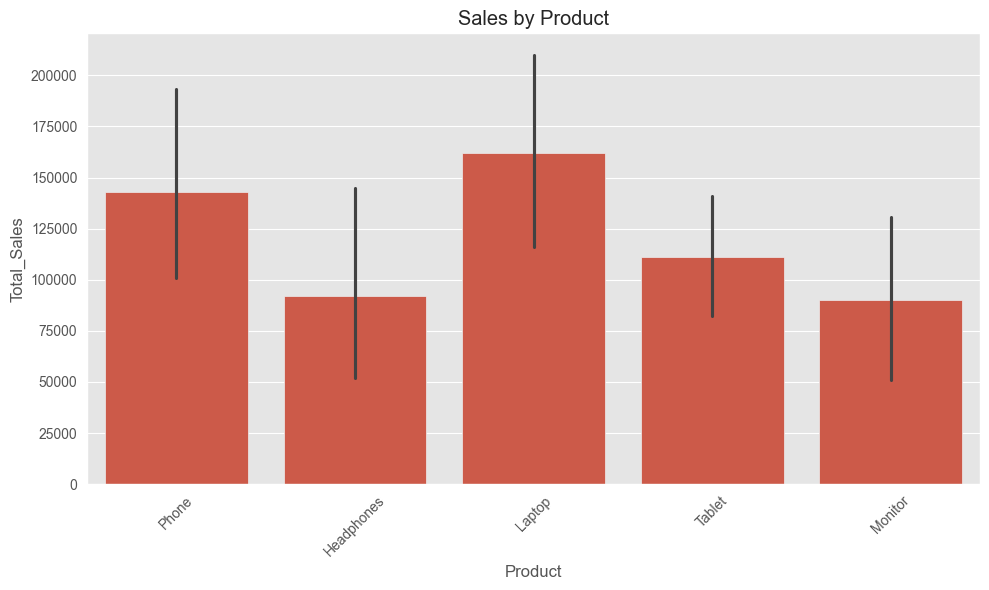

In [10]:
# ============================================
# PRODUCT SALES BAR CHART
# ============================================

plt.figure(figsize=(10,6))

sns.barplot(
    x='Product',
    y='Total_Sales',
    data=df
)

plt.title("Sales by Product")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

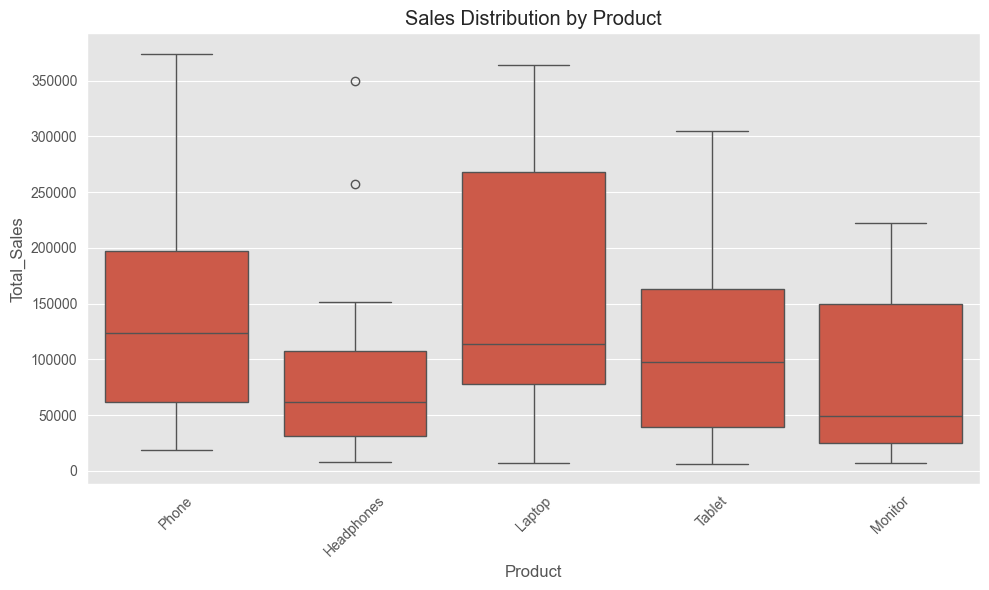

In [11]:
# ============================================
# BOX PLOT
# ============================================

plt.figure(figsize=(10,6))

sns.boxplot(
    x='Product',
    y='Total_Sales',
    data=df
)

plt.title("Sales Distribution by Product")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

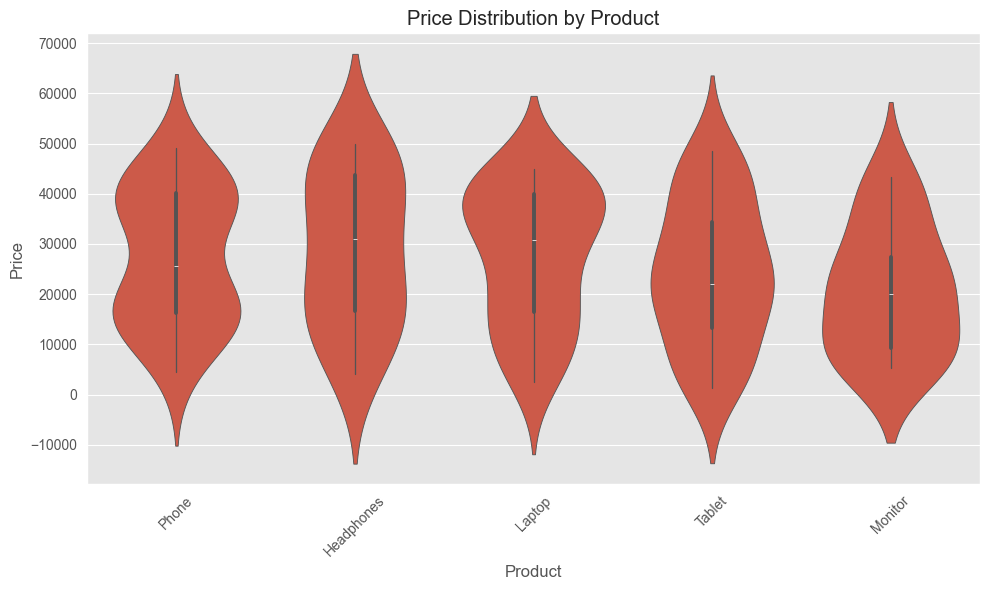

In [12]:
# ============================================
# VIOLIN PLOT
# ============================================

plt.figure(figsize=(10,6))

sns.violinplot(
    x='Product',
    y='Price',
    data=df
)

plt.title("Price Distribution by Product")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

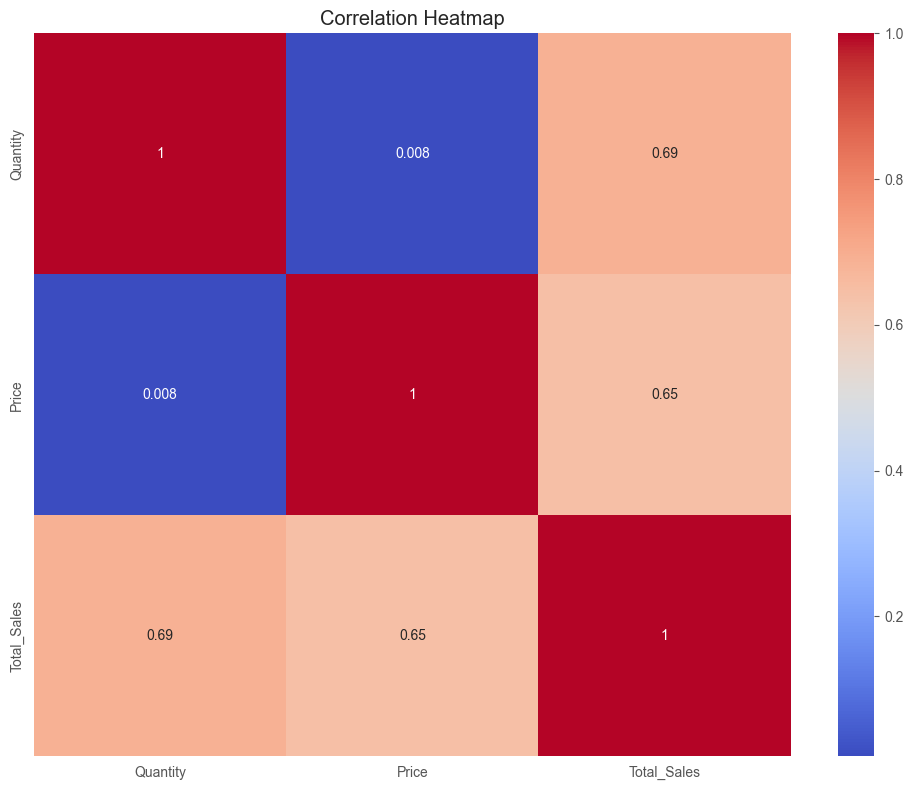

In [13]:
# ============================================
# CORRELATION HEATMAP
# ============================================

plt.figure(figsize=(10,8))

correlation = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

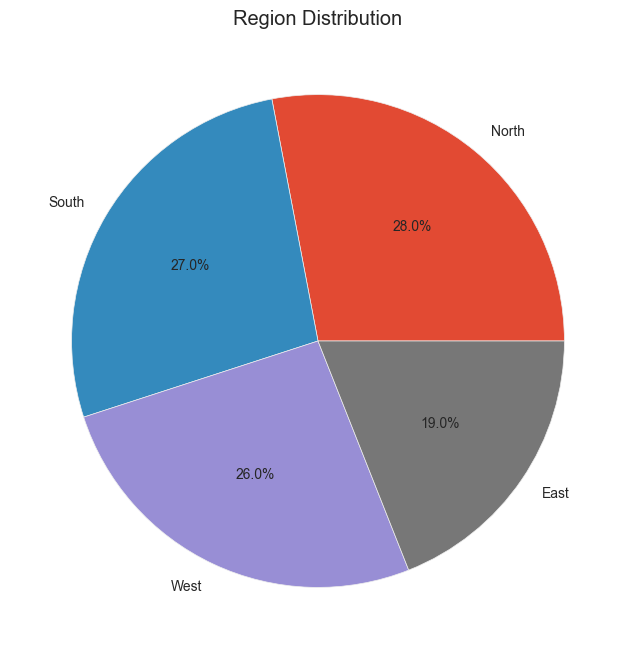

In [14]:
# ============================================
# REGION PIE CHART
# ============================================

region_counts = df['Region'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    region_counts,
    labels=region_counts.index,
    autopct='%1.1f%%'
)

plt.title("Region Distribution")

plt.show()

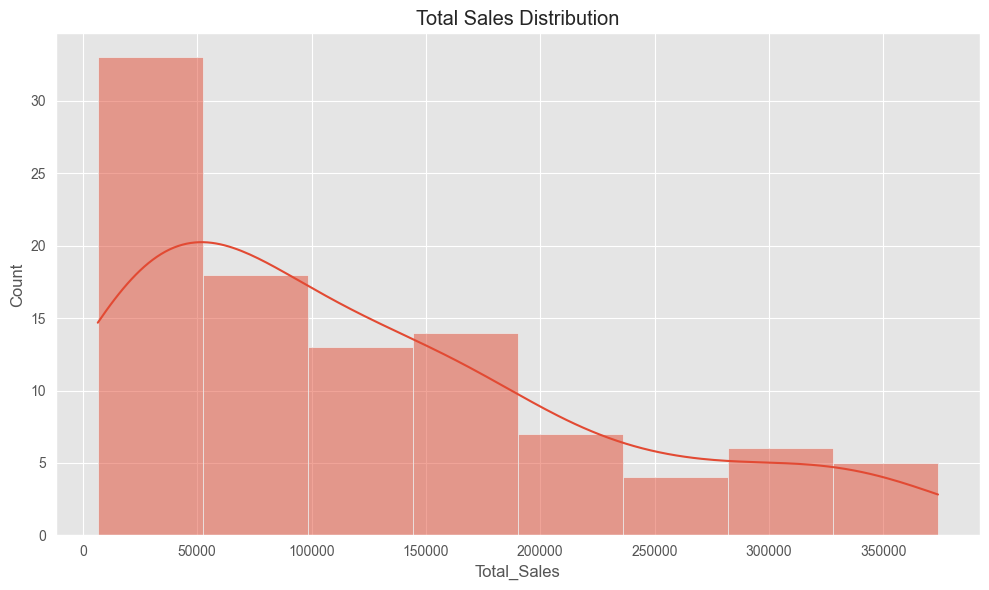

In [15]:
# ============================================
# HISTOGRAM
# ============================================

plt.figure(figsize=(10,6))

sns.histplot(
    df['Total_Sales'],
    kde=True
)

plt.title("Total Sales Distribution")

plt.tight_layout()

plt.show()

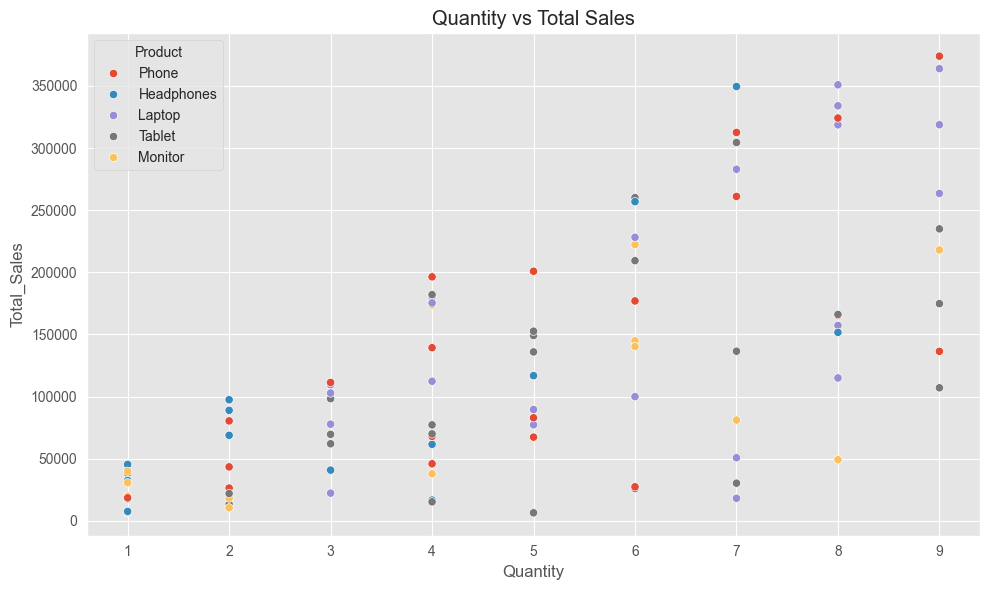

In [16]:
# ============================================
# SCATTER PLOT
# ============================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Quantity',
    y='Total_Sales',
    hue='Product',
    data=df
)

plt.title("Quantity vs Total Sales")

plt.tight_layout()

plt.show()

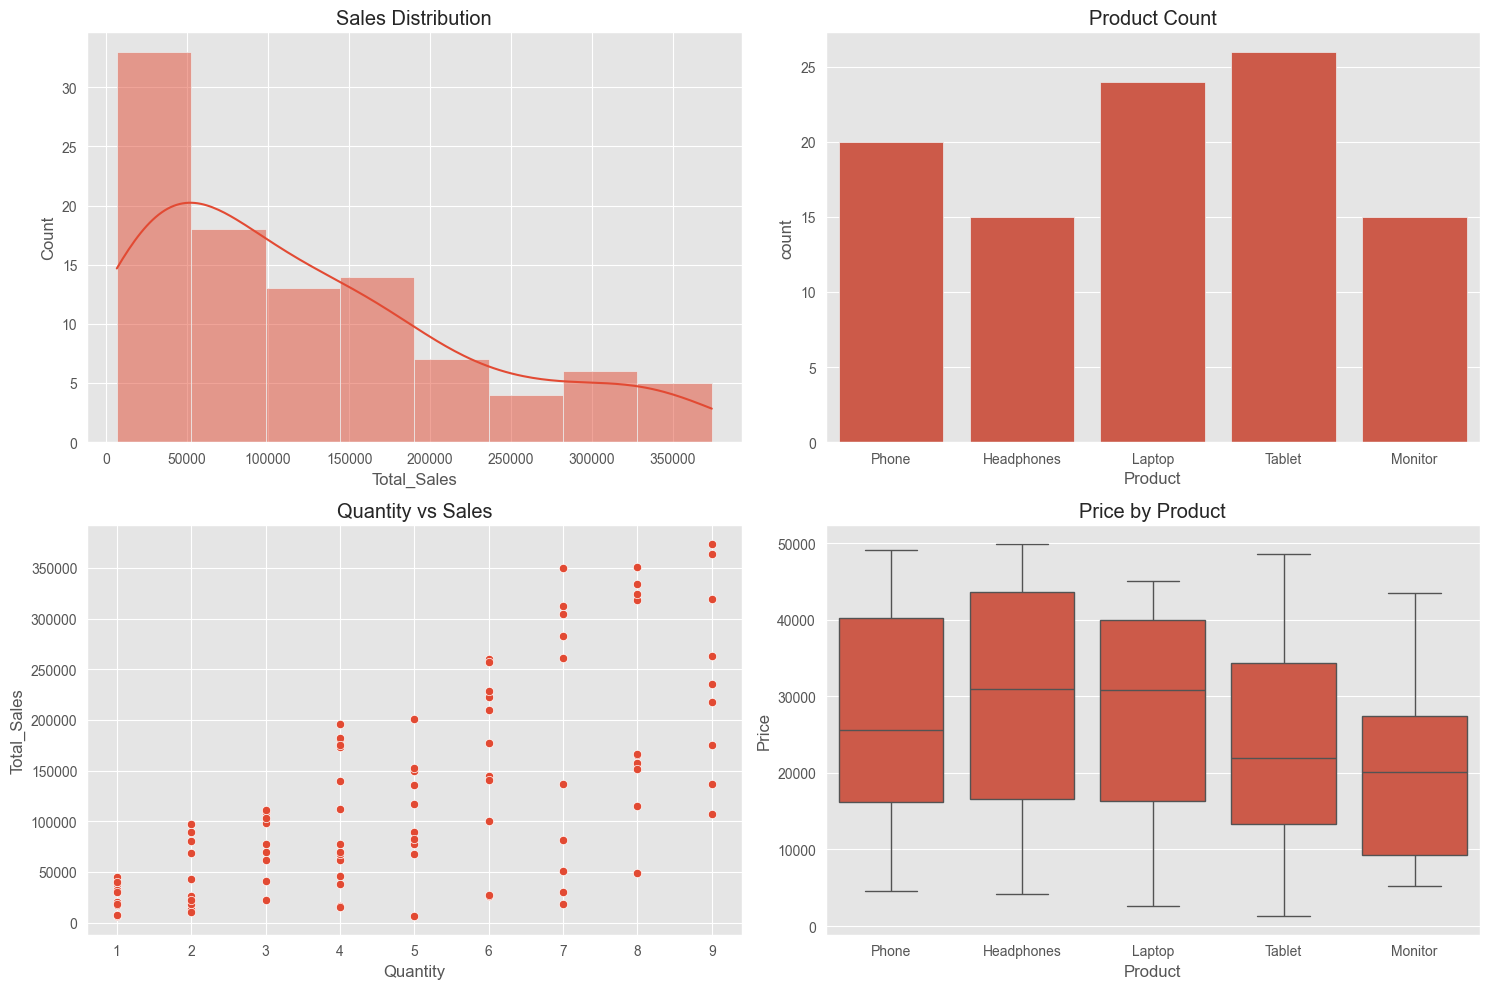

In [17]:
# ============================================
# MULTI-PLOT DASHBOARD
# ============================================

fig, axes = plt.subplots(2,2, figsize=(15,10))

# Histogram
sns.histplot(
    df['Total_Sales'],
    kde=True,
    ax=axes[0,0]
)

axes[0,0].set_title("Sales Distribution")

# Count Plot
sns.countplot(
    x='Product',
    data=df,
    ax=axes[0,1]
)

axes[0,1].set_title("Product Count")

# Scatter Plot
sns.scatterplot(
    x='Quantity',
    y='Total_Sales',
    data=df,
    ax=axes[1,0]
)

axes[1,0].set_title("Quantity vs Sales")

# Box Plot
sns.boxplot(
    x='Product',
    y='Price',
    data=df,
    ax=axes[1,1]
)

axes[1,1].set_title("Price by Product")

plt.tight_layout()

plt.show()

In [18]:
# ============================================
# INTERACTIVE SCATTER CHART
# ============================================

fig = px.scatter(
    df,
    x='Quantity',
    y='Total_Sales',
    color='Product',
    hover_data=df.columns,
    title='Interactive Quantity vs Sales'
)

fig.show()

In [19]:
# ============================================
# INTERACTIVE LINE CHART
# ============================================

daily_sales = df.groupby('Date')['Total_Sales'].sum().reset_index()

fig = px.line(
    daily_sales,
    x='Date',
    y='Total_Sales',
    title='Interactive Sales Trend'
)

fig.show()

In [20]:
# ============================================
# PROFESSIONAL DASHBOARD
# ============================================

fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=(
        'Sales Trend',
        'Sales by Product',
        'Price Distribution',
        'Quantity vs Sales'
    )
)

# Sales Trend
fig.add_trace(
    go.Scatter(
        x=daily_sales['Date'],
        y=daily_sales['Total_Sales'],
        mode='lines+markers',
        name='Sales Trend'
    ),
    row=1,
    col=1
)

# Product Sales
product_sales = df.groupby('Product')['Total_Sales'].sum().reset_index()

fig.add_trace(
    go.Bar(
        x=product_sales['Product'],
        y=product_sales['Total_Sales'],
        name='Product Sales'
    ),
    row=1,
    col=2
)

# Price Histogram
fig.add_trace(
    go.Histogram(
        x=df['Price'],
        name='Price Distribution'
    ),
    row=2,
    col=1
)

# Scatter Plot
fig.add_trace(
    go.Scatter(
        x=df['Quantity'],
        y=df['Total_Sales'],
        mode='markers',
        name='Quantity vs Sales'
    ),
    row=2,
    col=2
)

fig.update_layout(
    title='Interactive Sales Dashboard',
    height=800,
    width=1200,
    showlegend=True
)

fig.show()

In [21]:
# ============================================
# BUSINESS INSIGHTS
# ============================================

print("\n===== BUSINESS INSIGHTS =====")

# Total Sales
print("Total Sales:", df['Total_Sales'].sum())

# Average Sales
print("Average Sales:", df['Total_Sales'].mean())

# Best Product
best_product = df.groupby('Product')['Total_Sales'].sum().idxmax()

print("Best Performing Product:", best_product)

# Best Region
best_region = df.groupby('Region')['Total_Sales'].sum().idxmax()

print("Best Performing Region:", best_region)


===== BUSINESS INSIGHTS =====
Total Sales: 12365048
Average Sales: 123650.48
Best Performing Product: Laptop
Best Performing Region: North
